## Import Data

Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Read dataset

In [2]:
df0 = pd.read_csv('input/ecommerce_dataset_+1m.csv')
df0.head()

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
0,ORD-XAJI0,2024-10-14 11:20:05.496679,2024,10,14,11,20,5,No,Completed,...,Email,Mobile,Search,52.1,13,No,45.3,28.66,Medium,Yes
1,ORD-NHJ7X,2024-10-21 00:49:44.681065,2024,10,21,0,49,44,No,Completed,...,Google Ads,Desktop,Referral,36.2,15,No,97.1,33.91,Low,Yes
2,ORD-YTJXE,2025-03-17 19:49:36.983317,2025,3,17,19,49,36,No,Completed,...,Facebook,Tablet,Search,43.1,13,No,43.8,52.77,High,No
3,ORD-EIMVI,2024-09-27 06:24:44.913768,2024,9,27,6,24,44,No,Completed,...,Instagram,Mobile,Direct,39.5,18,Yes,96.9,38.15,Low,Yes
4,ORD-OR56F,2025-05-21 17:10:48.401882,2025,5,21,17,10,48,No,Completed,...,Facebook,Tablet,Social,28.0,3,Yes,45.8,33.05,High,Yes


In [3]:
df0.tail()

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
1000118,ORD-MH6TM,2024-08-21 19:30:06.902744,2024,8,21,19,30,6,No,Completed,...,Affiliate,Mobile,Search,13.6,1,Yes,99.8,45.23,High,Yes
1000119,ORD-ILXX0,2024-04-05 09:58:34.625191,2024,4,5,9,58,34,No,Cancelled,...,Google Ads,Tablet,Email,30.2,13,No,36.7,49.46,Low,Yes
1000120,ORD-O2H6B,2024-11-09 21:15:09.983331,2024,11,9,21,15,9,Yes,Completed,...,Google Ads,Desktop,Direct,43.4,1,No,51.2,45.83,High,Yes
1000121,ORD-EGD60,2025-10-17 12:48:19.451188,2025,10,17,12,48,19,No,Completed,...,Facebook,Mobile,Email,30.7,9,No,72.4,41.07,High,Yes
1000122,ORD-HBJAD,2025-04-17 15:30:36.405483,2025,4,17,15,30,36,No,Completed,...,Facebook,Desktop,Search,43.2,4,Yes,25.9,42.64,Low,Yes


Sort by order_date and reset index

In [4]:
df0.sort_values(by='order_date', inplace=True)
df0.reset_index(drop=True, inplace=True)

Information of all Columns

In [5]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000123 entries, 0 to 1000122
Data columns (total 62 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   order_id                  1000123 non-null  object 
 1   order_date                1000123 non-null  object 
 2   order_year                1000123 non-null  int64  
 3   order_month               1000123 non-null  int64  
 4   order_day                 1000123 non-null  int64  
 5   order_hour                1000123 non-null  int64  
 6   order_minute              1000123 non-null  int64  
 7   order_second              1000123 non-null  int64  
 8   is_weekend                1000123 non-null  object 
 9   order_status              1000123 non-null  object 
 10  return_reason             99879 non-null    object 
 11  customer_id               1000123 non-null  object 
 12  customer_name             1000123 non-null  object 
 13  gender                    1

Check null columns

In [6]:
print(df0.columns[df0.isnull().any()])

Index(['return_reason', 'customer_feedback', 'coupon_code'], dtype='object')


Check null value

In [7]:
col_null_sum = df0.isnull().sum()

col_null_sum[col_null_sum > 0]

return_reason        900244
customer_feedback    199617
coupon_code          500083
dtype: int64

Shape of dataset

In [8]:
df0.shape

(1000123, 62)

Check duplicate value

In [9]:
df0.duplicated().sum()

np.int64(0)

## Select columns for EDA

In [10]:
cols = ['order_id',
        'order_date',
        'product_id',
        'category',
        'unit_price_usd',
        'quantity',
        'discount_percent',
        'discount_amount_usd',
        'total_price_usd',
        'cost_usd',
        'profit_usd',
        'customer_id',
        'account_creation_date',
        'total_orders_by_customer',
        'coupon_used',
        'coupon_code',
        'campaign_source'
        ]

In [11]:
df1 = df0[cols].copy()
df1.head()

,order_id,order_date,product_id,category,unit_price_usd,quantity,discount_percent,discount_amount_usd,total_price_usd,cost_usd,profit_usd,customer_id,account_creation_date,total_orders_by_customer,coupon_used,coupon_code,campaign_source
0,ORD-5A2JR,2024-02-03 04:31:57.621140,PRD-I5G4,Electronics,291.95,2,15,87.58,496.32,268.28,228.04,CUS-PLY8L,2022-07-09,30,No,NaN,Email
1,ORD-C4O76,2024-02-03 04:33:50.281606,PRD-2IHW,Health,27.17,4,15,16.30,92.38,49.04,43.34,CUS-ZU9Q2,2021-09-26,40,No,NaN,Organic
2,ORD-MIP58,2024-02-03 04:34:13.452841,PRD-5JLE,Electronics,417.90,3,5,62.68,1191.02,827.07,363.95,CUS-QY61Z,2022-01-30,2,Yes,CPN-2H2,Organic
3,ORD-A9GBX,2024-02-03 04:34:14.421205,PRD-CMCX,Home,231.96,1,15,34.79,197.17,143.02,54.15,CUS-0WIYC,2022-05-05,45,Yes,CPN-S0X,Facebook
4,ORD-MI6OD,2024-02-03 04:35:56.872135,PRD-DRYT,Health,26.55,2,0,0.00,53.10,26.14,26.96,CUS-T4DSS,2021-07-16,20,Yes,CPN-DH5,Email


### Derived core transaction columns

_gmv_ : unit price * quantity

_is_promo_ : 0 for using promo and 1 for not using promo

_promo_depth_bucket_ : bucket for promo

    - No Promo: 0%

    - Low: (0-10%]

    - Medium: (10-20%]

    - High: (20-40%]

    - Extreme: (40-100%]

In [12]:
df1['gmv'] = df1['unit_price_usd'] * df1['quantity']
df1['is_promo'] = np.where(df1['discount_percent'] > 0, 1, 0)
df1['promo_depth_bucket'] = pd.cut(df1['discount_percent'],
                                   bins=[-1, 0, 10, 20, 40, 100],
                                   labels=['No Promo', 'Low', 'Medium', 'High', 'Extreme']
                                   )

In [13]:
df1[(df1['promo_depth_bucket']=='No Promo') & (df1['is_promo']==1)]

,order_id,order_date,product_id,category,unit_price_usd,quantity,discount_percent,discount_amount_usd,total_price_usd,cost_usd,profit_usd,customer_id,account_creation_date,total_orders_by_customer,coupon_used,coupon_code,campaign_source,gmv,is_promo,promo_depth_bucket


### Derived customer segmentation columns

_customer_tenure_days_ : order date - first order date

_days_since_last_order_ : order date - last order date

_total_orders_to_date_ : how many orders a customer has done until order date

In [14]:
# Ensure order_date is a datetime
df1['order_date'] = pd.to_datetime(df1['order_date'])

# Sort the data by date
df1 = df1.sort_values(by=['customer_id', 'order_date'])

# Calculate first order date per customer and tenure in days
first_order = df1.groupby('customer_id')['order_date'].transform('min')
df1['customer_tenure_days'] = (df1['order_date'] - first_order).dt.days

# Calculate days since previous order for each customer
last_order = df1.groupby('customer_id')['order_date'].shift(1) # groupby.shift(1) to get the previous order_date within each customer
df1['days_since_last_order'] = (df1['order_date'] - last_order).dt.days

# For first orders the value will be NaN. Convert NaN into 0
df1['days_since_last_order'] = df1['days_since_last_order'].fillna(0).astype(int)

# Calculate cumulative order count
df1['total_orders_to_date'] = (df1.groupby('customer_id').cumcount() + 1)

def segment_customer(order_count):
    if order_count == 1:
        return "New"
    elif 2 <= order_count <= 4:
        return "Repeat"
    else:
        return "Frequent"

df1['customer_segment'] = df1['total_orders_to_date'].apply(segment_customer)

In [15]:
# Quick check
df1[df1['customer_segment']=="Frequent"][['customer_id','order_date','days_since_last_order','customer_tenure_days','customer_segment']]

,customer_id,order_date,days_since_last_order,customer_tenure_days,customer_segment


In [16]:
df1['total_orders_to_date'].describe()

count    1.000123e+06
mean     1.008226e+00
std      9.086428e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: total_orders_to_date, dtype: float64

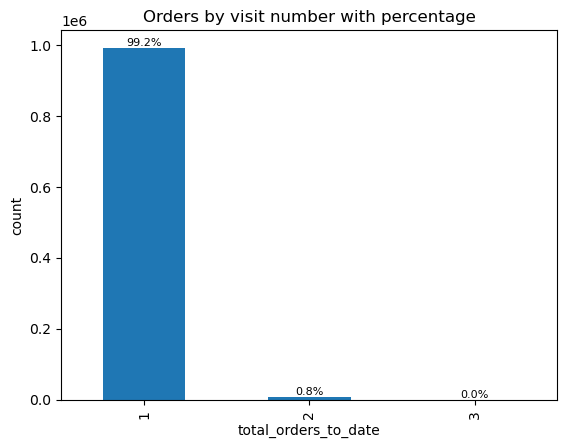

In [17]:

# include percentage of total
counts = df1['total_orders_to_date'].value_counts().sort_index() #total orders to date becomes the index, count of rows becomes the value
counts_df = (
    counts.rename_axis('total_orders_to_date')
          .reset_index(name='n_rows') #turns the index into a column and names the count column 'n_rows'
)
total = counts_df['n_rows'].sum()
counts_df['percentage'] = counts_df['n_rows'] / total * 100

counts_df

# optionally plot with percentages as labels
ax = counts_df.plot(kind='bar', x='total_orders_to_date', y='n_rows', legend=False)
for p, pct in zip(ax.patches, counts_df['percentage']):
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=8)
plt.ylabel('count')
plt.title('Orders by visit number with percentage')
plt.show()


In [18]:
print(counts)

total_orders_to_date
1    991945
2      8129
3        49
Name: count, dtype: int64


In [22]:
counts_df

,total_orders_to_date,n_rows,percentage
0,1,991945,99.182301
1,2,8129,0.812800
2,3,49,0.004899


The _total_orders_to_date_ was meant to be used for behavioral depth analysis. As the distribution is unusually extreme, we won't be going further on this.

In [20]:
df1[df1['days_since_last_order']>0][['customer_id','order_date','days_since_last_order']]

,customer_id,order_date,days_since_last_order
449256,CUS-002ZC,2024-12-27 13:43:23.168144,93
890948,CUS-00C5B,2025-11-15 02:59:35.561786,351
837500,CUS-0131E,2025-10-07 03:14:40.950769,219
960045,CUS-01518,2026-01-04 12:38:19.337625,42
639848,CUS-016UA,2025-05-15 19:56:47.669096,64
...,...,...,...
17272,CUS-ZZJOJ,2024-02-15 15:24:27.426214,1
781363,CUS-ZZN8Y,2025-08-27 01:16:54.005434,471
953539,CUS-ZZQCW,2025-12-30 16:37:51.479184,210
935853,CUS-ZZSV5,2025-12-17 19:19:21.992896,666


In [21]:
df1[df1['customer_tenure_days']>0]

,order_id,order_date,product_id,category,unit_price_usd,quantity,discount_percent,discount_amount_usd,total_price_usd,cost_usd,...,coupon_used,coupon_code,campaign_source,gmv,is_promo,promo_depth_bucket,customer_tenure_days,days_since_last_order,total_orders_to_date,customer_segment
449256,ORD-TP5RH,2024-12-27 13:43:23.168144,PRD-9MCQ,Health,173.23,3,10,51.97,467.72,242.04,...,No,NaN,Google Ads,519.69,1,Low,93,93,2,Repeat
890948,ORD-6ZH6R,2025-11-15 02:59:35.561786,PRD-QQJ8,Health,163.78,1,0,0.00,163.78,101.99,...,Yes,CPN-J9M,Affiliate,163.78,0,No Promo,351,351,2,Repeat
837500,ORD-W47RC,2025-10-07 03:14:40.950769,PRD-TNXB,Clothing,23.19,1,0,0.00,23.19,9.90,...,No,NaN,Instagram,23.19,0,No Promo,219,219,2,Repeat
960045,ORD-F23XG,2026-01-04 12:38:19.337625,PRD-RUEH,Home,93.10,1,10,9.31,83.79,62.14,...,No,NaN,Organic,93.10,1,Low,42,42,2,Repeat
639848,ORD-EN728,2025-05-15 19:56:47.669096,PRD-D6FO,Clothing,148.88,2,20,59.55,238.21,120.16,...,Yes,CPN-PQK,Affiliate,297.76,1,Medium,64,64,2,Repeat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17272,ORD-GX68U,2024-02-15 15:24:27.426214,PRD-U8DJ,Home,283.95,5,5,70.99,1348.76,631.55,...,Yes,CPN-73C,Instagram,1419.75,1,Low,1,1,2,Repeat
781363,ORD-R06V0,2025-08-27 01:16:54.005434,PRD-59RQ,Clothing,44.03,5,0,0.00,220.15,121.95,...,Yes,CPN-IZ5,Facebook,220.15,0,No Promo,471,471,2,Repeat
953539,ORD-9ZXUQ,2025-12-30 16:37:51.479184,PRD-GYDY,Clothing,62.44,2,10,12.49,112.39,85.04,...,Yes,CPN-FDS,Facebook,124.88,1,Low,210,210,2,Repeat
935853,ORD-VLM7U,2025-12-17 19:19:21.992896,PRD-EA2F,Home,282.76,5,0,0.00,1413.80,947.60,...,Yes,CPN-D62,Facebook,1413.80,0,No Promo,666,666,2,Repeat


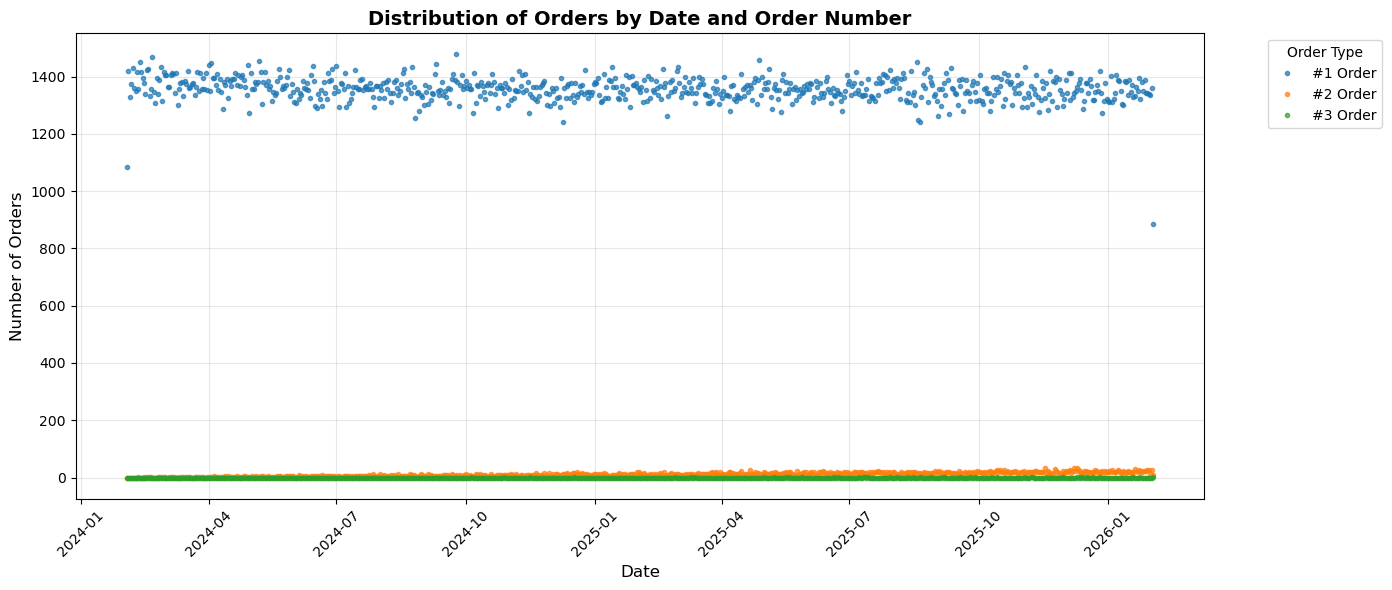


Date Range: 2024-02-03 to 2026-02-02
Order numbers tracked: [1, 2, 3]... (showing first 10)


In [37]:
# Create a new column for order date without time
df1['order_date_only'] = df1['order_date'].dt.date

# Distribution of orders by date and order number
# Group by order_date_only and total_orders_to_date, then count
orders_by_date = df1.groupby(['order_date_only', 'total_orders_to_date']).size().reset_index(name='count')

# Create pivot table for easier plotting
pivot_df = orders_by_date.pivot(index='order_date_only', columns='total_orders_to_date', values='count').fillna(0)

# Create the chart
plt.figure(figsize=(14, 6))

# Plot lines for each order number
for order_num in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[order_num], marker='.', label=f'#{int(order_num)} Order', alpha=0.7, linewidth=0)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.title('Distribution of Orders by Date and Order Number', fontsize=14, fontweight='bold')
plt.legend(title='Order Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nDate Range: {df1['order_date_only'].min()} to {df1['order_date_only'].max()}")
print(f"Order numbers tracked: {sorted(pivot_df.columns.astype(int))[:10]}... (showing first 10)")

In [25]:
orders_by_date.head()

,order_date,total_orders_to_date,count
0,2024-02-03 04:31:57.621140,1,1
1,2024-02-03 04:33:50.281606,1,1
2,2024-02-03 04:34:13.452841,1,1
3,2024-02-03 04:34:14.421205,1,1
4,2024-02-03 04:35:56.872135,1,1


In [30]:
pivot_df[pivot_df[2]>0]

total_orders_to_date,1,2,3
order_date,,,
2024-02-11 10:44:14.767471,0.0,1.0,0.0
2024-02-15 04:17:07.318336,0.0,1.0,0.0
2024-02-15 15:24:27.426214,0.0,1.0,0.0
2024-02-17 21:07:12.774525,0.0,1.0,0.0
2024-02-18 21:18:19.663393,0.0,1.0,0.0
...,...,...,...
2026-02-02 07:53:04.179031,0.0,1.0,0.0
2026-02-02 09:09:13.384364,0.0,1.0,0.0
2026-02-02 12:05:53.616473,0.0,1.0,0.0
